In [43]:
RUN_TARGET = "local"  # "colab" | "local"


## Setup Instructions

### Purpose
This notebook performs a three-stage in silico mutagenesis analysis on the baseline classifier. It assumes a trained baseline checkpoint already exists and that raw per-residue IG scores are available in the saved probe rows.

### Three-stage workflow
1. Validate IG-important residues by masking the top-k% residues and measuring the drop in allergenicity probability.
2. Run saturation mutagenesis on the validated positions at the best k threshold.
3. Annotate the reducing substitutions with coarse biochemical property changes.


# 09 - In Silico Mutagenesis

This notebook is downstream of probe generation. It does not retrain the baseline model and it does not recompute IG from scratch. Instead, it loads saved IG artifacts, validates a percentage-based top-k masking strategy, and then explores single-residue substitutions on the validated positions.

All outputs from this notebook are written into a dedicated subfolder: `results/insilico_mutagenesis/`. That keeps the root `results/` directory cleaner and makes it easier to version, inspect, or delete mutagenesis-specific artifacts as one bundle.


In [44]:
import ast
import importlib
import importlib.metadata as _md
import json
import subprocess as _sp
import sys
from pathlib import Path

# Allow imports from the src-layout package without a root-level shim.
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    _src_dir = _candidate / "src"
    if (_src_dir / "xallergen").exists() and str(_src_dir) not in sys.path:
        sys.path.insert(0, str(_src_dir))
        break

if RUN_TARGET == "colab":
    _required = {
        "numpy": "1.26.4",
        "pandas": "2.3.2",
        "scikit-learn": "1.8.0",
        "transformers": "4.48.1",
        "huggingface-hub": "0.36.2",
        "seaborn": "0.13.2",
        "matplotlib": "3.10.6",
    }

    def _version_matches(name: str, expected: str) -> bool:
        try:
            return _md.version(name) == expected
        except _md.PackageNotFoundError:
            return False

    _missing_or_mismatched = [
        f"{name}=={version}"
        for name, version in _required.items()
        if not _version_matches(name, version)
    ]

    if _missing_or_mismatched:
        print("Installing:", ", ".join(_missing_or_mismatched))
        _sp.run(
            [sys.executable, "-m", "pip", "install", "-q", "--upgrade", *_missing_or_mismatched],
            check=True,
        )
        raise SystemExit(
            "Colab environment updated. Restart the runtime once, then rerun the notebook from the top."
        )

    from google.colab import drive as _drive

    _drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive/XAllergen2.0")
    DRIVE_MODELS = DRIVE_ROOT / "models"
    DRIVE_RESULTS = DRIVE_ROOT / "results"
    RUNTIME_ROOT = Path("/content/XAllergen2.0")
    if str(RUNTIME_ROOT) not in sys.path:
        sys.path.insert(0, str(RUNTIME_ROOT))
    _SRC_DIR = RUNTIME_ROOT / "src"
    if _SRC_DIR.exists() and str(_SRC_DIR) not in sys.path:
        sys.path.insert(0, str(_SRC_DIR))

import xallergen.baseline_notebook_utils as baseline_notebook_utils
importlib.reload(baseline_notebook_utils)
from xallergen.baseline_notebook_utils import *

if RUN_TARGET != "colab":
    configure_matplotlib_cache(Path.cwd())
    PROJECT_ROOT = find_project_root(Path.cwd())
    DEVICE = detect_device()
    print_runtime_context(DEVICE, PROJECT_ROOT)
    MODELS_DIR = PROJECT_ROOT / "models"
    RESULTS_DIR = PROJECT_ROOT / "results"
else:
    PROJECT_ROOT = RUNTIME_ROOT
    DEVICE = detect_device()
    print_runtime_context(DEVICE, PROJECT_ROOT)
    MODELS_DIR = DRIVE_MODELS if DRIVE_MODELS.exists() else PROJECT_ROOT / "models"
    RESULTS_DIR = DRIVE_RESULTS if DRIVE_RESULTS.exists() else PROJECT_ROOT / "results"

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ISM_RESULTS_DIR = RESULTS_DIR / "insilico_mutagenesis"
ISM_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

BASELINE_CHECKPOINT_PATH = MODELS_DIR / "baseline_frozen_esm2.pt"
RAW_IG_ROWS_PATH = RESULTS_DIR / "baseline_probe_rows.csv"
if not RAW_IG_ROWS_PATH.exists():
    fallback_path = RESULTS_DIR / "baseline_probing_rows.csv"
    if fallback_path.exists():
        RAW_IG_ROWS_PATH = fallback_path

TEST_WITH_MASKS_CSV = DATA_DIR / "positives_splitB.csv"

model, baseline_checkpoint = load_baseline_checkpoint(BASELINE_CHECKPOINT_PATH, DEVICE)
tokenizer = build_tokenizer()

positive_test_df = pd.read_csv(TEST_WITH_MASKS_CSV).copy()
positive_test_df["sequence_id"] = positive_test_df.get("sequence_id", positive_test_df["accession"]).astype(str)
positive_test_df["epitope_label"] = [
    parse_epitope_label(seq, start, end)
    for seq, start, end in zip(
        positive_test_df["sequence"],
        positive_test_df["epitope_start"],
        positive_test_df["epitope_end"],
    )
]
positive_test_df["seq_len"] = positive_test_df["sequence"].str.len().astype(int)
positive_test_df["n_epitope_residues"] = positive_test_df["epitope_label"].map(lambda arr: int(np.asarray(arr).sum()))
positive_test_df["epitope_density"] = positive_test_df["n_epitope_residues"] / positive_test_df["seq_len"]
sequence_lookup_df = positive_test_df[["sequence_id", "accession", "sequence", "seq_len", "epitope_density"]].drop_duplicates()
sequence_lookup = sequence_lookup_df.set_index("sequence_id").to_dict(orient="index")

raw_ig_df = pd.read_csv(RAW_IG_ROWS_PATH)
print(f"Using baseline checkpoint: {BASELINE_CHECKPOINT_PATH}")
print(f"Using raw IG artifact: {RAW_IG_ROWS_PATH}")
print(f"Mutagenesis output directory: {ISM_RESULTS_DIR}")
print(f"Loaded splitB positives with epitope masks: {len(sequence_lookup_df)} proteins")


RUN_TARGET: local
Device: mps
Project root: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0
GPU configuration:
  backend: Apple Metal Performance Shaders (MPS)
  built with MPS: True
  MPS available: True


Some weights of EsmModel were not initialized from the model checkpoint at /Users/jianzhouyao/.cache/huggingface/hub/models--facebook--esm2_t6_8M_UR50D/snapshots/c731040fcd8d73dceaa04b0a8e6329b345b0f5df and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using baseline checkpoint: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/models/baseline_frozen_esm2.pt
Using raw IG artifact: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/baseline_probing_rows.csv
Mutagenesis output directory: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis
Loaded splitB positives with epitope masks: 58 proteins


## Analysis Parameters

- `K_PERCENTAGES` defines the top-k sweep as a fraction of sequence length, never as a fixed integer.
- `MIN_DELTA_P` is the minimum masking-induced probability drop required to count a protein as validated.
- `MIN_P_BASE` restricts the analysis to high-confidence allergen predictions.


In [45]:
K_PERCENTAGES = [0.05, 0.10, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]   # top 5%, 10%, 20%, 25%, 30%, 35%, 40%, 45%, 50% of residues
MIN_DELTA_P = 0.05                     # minimum drop to count as validated
MIN_P_BASE = 0.70                      # only high-confidence allergens, the sequence-level allergenicity model output probability must be over 0.70 to be included in the analysis


In [46]:
# --- Results refresh/reuse switch ---
REFRESH_ISM_RESULTS = True  # False: reuse CSVs and regenerate plots; True: rerun Stages 1-3 and refresh CSVs

IG_VALIDATION_SWEEP_CSV = ISM_RESULTS_DIR / "ig_validation_sweep.csv"
SATURATION_MUTAGENESIS_RESULTS_CSV = ISM_RESULTS_DIR / "saturation_mutagenesis_results.csv"
SATURATION_MUTAGENESIS_ANNOTATED_CSV = ISM_RESULTS_DIR / "saturation_mutagenesis_annotated.csv"

if not REFRESH_ISM_RESULTS:
    required_result_paths = [
        IG_VALIDATION_SWEEP_CSV,
        SATURATION_MUTAGENESIS_RESULTS_CSV,
        SATURATION_MUTAGENESIS_ANNOTATED_CSV,
    ]
    missing_result_paths = [path for path in required_result_paths if not path.exists()]
    if missing_result_paths:
        raise FileNotFoundError(
            "Cannot reuse precomputed ISM results because these files are missing: "
            + ", ".join(str(path) for path in missing_result_paths)
            + ". Set REFRESH_ISM_RESULTS=True to regenerate them."
        )

    ig_validation_sweep_df = pd.read_csv(IG_VALIDATION_SWEEP_CSV)
    saturation_mutagenesis_df = pd.read_csv(SATURATION_MUTAGENESIS_RESULTS_CSV)
    annotated_mutagenesis_df = pd.read_csv(SATURATION_MUTAGENESIS_ANNOTATED_CSV)

    expected_k_percentages = {round(float(value), 10) for value in K_PERCENTAGES}
    loaded_k_percentages = {round(float(value), 10) for value in ig_validation_sweep_df["k_pct"].unique()}
    if loaded_k_percentages != expected_k_percentages:
        missing_k = sorted(expected_k_percentages - loaded_k_percentages)
        extra_k = sorted(loaded_k_percentages - expected_k_percentages)
        print(
            "Warning: loaded ig_validation_sweep.csv does not match current K_PERCENTAGES. "
            f"Missing k values: {missing_k}; extra k values: {extra_k}. "
            "Plots will use the k values present in the loaded CSV. "
            "Set REFRESH_ISM_RESULTS=True to regenerate the sweep with current K_PERCENTAGES."
        )

    # Reconstruct best_k_pct from the sweep data using the same selection logic.
    summary_rows = []
    for k_pct, group_df in ig_validation_sweep_df.groupby("k_pct", sort=True):
        validated_values = group_df["validated"].astype(float).to_numpy()
        summary_rows.append({
            "k_pct": float(k_pct),
            "pct_validated": float(validated_values.mean()),
            "mean_delta_p": float(group_df["delta_p"].mean()),
        })
    summary_df = pd.DataFrame(summary_rows)
    best_k_row = summary_df.sort_values(
        ["pct_validated", "mean_delta_p", "k_pct"],
        ascending=[False, False, True],
    ).iloc[0]
    best_k_pct = float(best_k_row["k_pct"])
    best_k_validation_df = ig_validation_sweep_df.loc[
        (ig_validation_sweep_df["k_pct"] == best_k_pct) &
        (ig_validation_sweep_df["delta_p"] > MIN_DELTA_P)
    ].copy()

    loaded_k_label = ", ".join(f"{int(round(value * 100))}%" for value in sorted(loaded_k_percentages))
    print(
        f"Reusing precomputed ISM results. Loaded k values: {loaded_k_label}. "
        f"best_k_pct={best_k_pct:.2f}, n_validated={len(best_k_validation_df)}"
    )
else:
    print("REFRESH_ISM_RESULTS=True: recomputing Stages 1-3 and refreshing result CSVs.")


REFRESH_ISM_RESULTS=True: recomputing Stages 1-3 and refreshing result CSVs.


## Stage 1: Functional Validation Sweep

This stage loads saved raw IG vectors, sweeps across multiple percentage-based top-k thresholds, and tests whether masking those residues lowers the baseline allergenicity probability.

Output written by this stage:
- `ig_validation_sweep.csv` in `results/insilico_mutagenesis/`


In [25]:
if REFRESH_ISM_RESULTS:
    def _forward_prob(sequence: str) -> float:
        encodings = tokenizer(
            sequence,
            add_special_tokens=False,
            padding=False,
            truncation=False,
            return_tensors="pt",
        )
        encodings = {key: value.to(DEVICE) for key, value in encodings.items()}
        with torch.no_grad():
            outputs = model(encodings["input_ids"], encodings["attention_mask"])
        return float(torch.sigmoid(outputs["logits"]).item())


    def _parse_score_array(value) -> np.ndarray:
        if isinstance(value, np.ndarray):
            return value.astype(np.float32)
        if isinstance(value, list):
            return np.asarray(value, dtype=np.float32)
        if pd.isna(value):
            raise ValueError("Encountered missing IG score payload.")
        parsed = value
        if isinstance(value, str):
            try:
                parsed = json.loads(value)
            except json.JSONDecodeError:
                parsed = ast.literal_eval(value)
        arr = np.asarray(parsed, dtype=np.float32)
        if arr.ndim != 1:
            raise ValueError(f"Expected 1D IG score array, got shape {arr.shape}.")
        return arr


    raw_ig_column_candidates = [
        "ig_scores",
        "ig_scores_json",
        "integrated_gradients_scores",
        "integrated_gradients_scores_json",
    ]
    raw_ig_score_column = next((col for col in raw_ig_column_candidates if col in raw_ig_df.columns), None)
    if raw_ig_score_column is None:
        raise ValueError(
            "The baseline IG artifact does not contain raw per-residue IG scores. "
            f"Checked {RAW_IG_ROWS_PATH} for columns {raw_ig_column_candidates}. "
            "The current repo artifact only stores summary probe metrics, so stage 1 cannot proceed "
            "without a saved raw-IG export."
        )

    raw_id_column = "sequence_id" if "sequence_id" in raw_ig_df.columns else "accession"
    ig_method_mask = raw_ig_df["method"].astype(str).str.lower().eq("integrated_gradients") if "method" in raw_ig_df.columns else pd.Series(True, index=raw_ig_df.index)
    raw_ig_scores_by_id = {
        str(row[raw_id_column]): _parse_score_array(row[raw_ig_score_column])
        for _, row in raw_ig_df.loc[ig_method_mask].iterrows()
    }

    validation_rows = []
    for row in sequence_lookup_df.itertuples(index=False):
        sequence_id = str(row.sequence_id)
        sequence = str(row.sequence)
        p_base = _forward_prob(sequence)
        if p_base <= MIN_P_BASE:
            continue
        ig_scores = raw_ig_scores_by_id.get(sequence_id)
        if ig_scores is None and str(row.accession) in raw_ig_scores_by_id:
            ig_scores = raw_ig_scores_by_id[str(row.accession)]
        if ig_scores is None:
            continue
        if len(ig_scores) != len(sequence):
            raise ValueError(
                f"IG score length mismatch for {sequence_id}: len(scores)={len(ig_scores)} vs len(sequence)={len(sequence)}"
            )
        for k_pct in K_PERCENTAGES:
            result = validate_ig_residues_by_masking(
                model=model,
                tokenizer=tokenizer,
                sequence=sequence,
                ig_scores=ig_scores,
                device=DEVICE,
                k_pct=k_pct,
            )
            validation_rows.append(
                {
                    "sequence_id": sequence_id,
                    "k_pct": float(result["k_pct"]),
                    "k_absolute": int(result["k_absolute"]),
                    "p_base": float(result["p_base"]),
                    "p_masked": float(result["p_masked"]),
                    "delta_p": float(result["delta_p"]),
                    "validated": bool(result["delta_p"] > MIN_DELTA_P),
                    "top_k_indices_json": json.dumps(result["top_k_indices"]),
                }
            )

    ig_validation_sweep_df = pd.DataFrame(validation_rows)
    IG_VALIDATION_SWEEP_CSV = ISM_RESULTS_DIR / "ig_validation_sweep.csv"
    ig_validation_sweep_df.to_csv(IG_VALIDATION_SWEEP_CSV, index=False)
    print(f"Saved IG validation sweep to: {IG_VALIDATION_SWEEP_CSV}")
    ig_validation_sweep_df[["sequence_id", "k_pct", "k_absolute", "p_base", "p_masked", "delta_p", "validated"]].head()


Saved IG validation sweep to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/ig_validation_sweep.csv


## Stage 1 Summary

The left panel shows the distribution of masking-induced `delta_p` values for each k threshold. The right panel summarizes the fraction of proteins that pass the validation threshold, with 95% bootstrap confidence intervals.

Output written by this stage:
- `ig_validation_sweep.png` in `results/insilico_mutagenesis/`


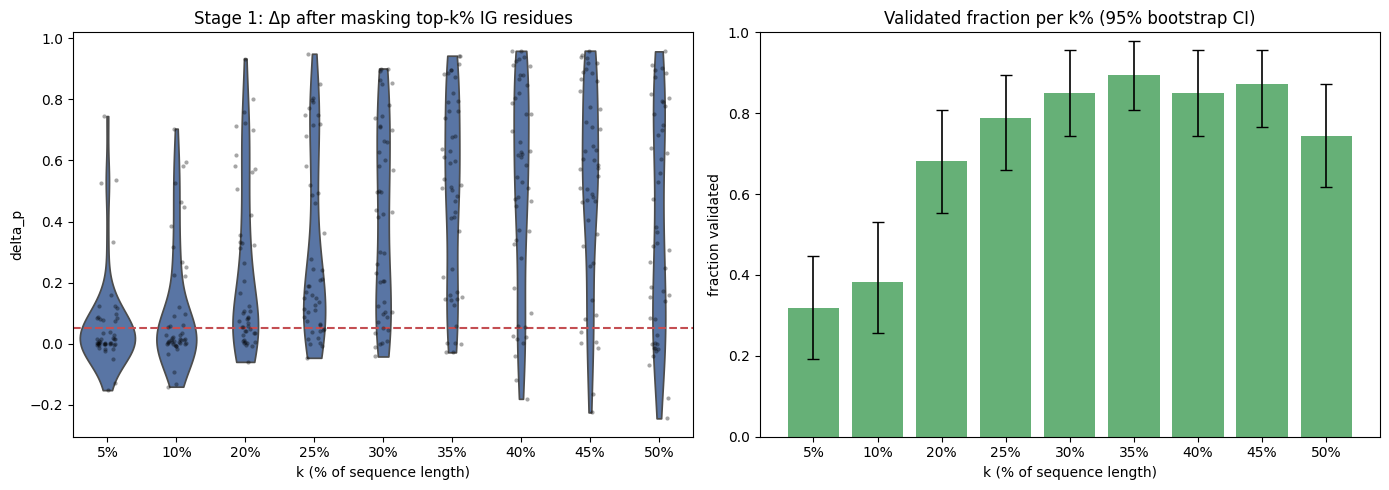

Saved sweep plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/ig_validation_sweep.png
 k_pct  k_absolute_mean  n_validated  pct_validated
  0.05        12.595745           15       0.319149
  0.10        24.829787           18       0.382979
  0.20        49.170213           32       0.680851
  0.25        61.170213           37       0.787234
  0.30        73.553191           40       0.851064
  0.35        85.617021           42       0.893617
  0.40        97.787234           40       0.851064
  0.45       110.042553           41       0.872340
  0.50       121.978723           35       0.744681


In [26]:
def bootstrap_ci_mean(values, n_bootstrap: int = 1000, random_state: int = 42) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    mean_value = float(values.mean())
    if values.size == 1:
        return mean_value, mean_value, mean_value
    rng = np.random.default_rng(random_state)
    boot = np.empty(n_bootstrap, dtype=float)
    for idx in range(n_bootstrap):
        sample = rng.choice(values, size=values.size, replace=True)
        boot[idx] = sample.mean()
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return mean_value, float(ci_low), float(ci_high)


IG_VALIDATION_SWEEP_PNG = ISM_RESULTS_DIR / "ig_validation_sweep.png"
summary_rows = []
for k_pct, group_df in ig_validation_sweep_df.groupby("k_pct", sort=True):
    validated_values = group_df["validated"].astype(float).to_numpy()
    pct_validated, ci_low, ci_high = bootstrap_ci_mean(validated_values, n_bootstrap=1000, random_state=42)
    summary_rows.append(
        {
            "k_pct": float(k_pct),
            "k_absolute_mean": float(group_df["k_absolute"].mean()),
            "n_validated": int(group_df["validated"].sum()),
            "pct_validated": float(pct_validated),
            "pct_validated_ci_low": float(ci_low),
            "pct_validated_ci_high": float(ci_high),
            "n_proteins": int(len(group_df)),
            "mean_delta_p": float(group_df["delta_p"].mean()),
        }
    )
summary_df = pd.DataFrame(summary_rows).sort_values("k_pct").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = ig_validation_sweep_df.copy()
plot_df["k_label"] = plot_df["k_pct"].map(lambda value: f"{int(round(value * 100))}%")
order = [f"{int(round(value * 100))}%" for value in summary_df["k_pct"]]

sns.violinplot(data=plot_df, x="k_label", y="delta_p", order=order, inner=None, cut=0, ax=axes[0], color="#4C72B0")
sns.stripplot(data=plot_df, x="k_label", y="delta_p", order=order, ax=axes[0], color="black", alpha=0.35, size=3, jitter=0.15)
axes[0].axhline(MIN_DELTA_P, color="#C44E52", linestyle="--", linewidth=1.5)
axes[0].set_title("Stage 1: Δp after masking top-k% IG residues")
axes[0].set_xlabel("k (% of sequence length)")
axes[0].set_ylabel("delta_p")

x_positions = np.arange(len(summary_df))
heights = summary_df["pct_validated"].to_numpy()
yerr = np.vstack([
    heights - summary_df["pct_validated_ci_low"].to_numpy(),
    summary_df["pct_validated_ci_high"].to_numpy() - heights,
])
axes[1].bar(x_positions, heights, color="#55A868", alpha=0.9)
axes[1].errorbar(x_positions, heights, yerr=yerr, fmt="none", ecolor="black", capsize=4, linewidth=1.2)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(order)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Validated fraction per k% (95% bootstrap CI)")
axes[1].set_xlabel("k (% of sequence length)")
axes[1].set_ylabel("fraction validated")

plt.tight_layout()
plt.savefig(IG_VALIDATION_SWEEP_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved sweep plot to: {IG_VALIDATION_SWEEP_PNG}")
print(summary_df[["k_pct", "k_absolute_mean", "n_validated", "pct_validated"]].to_string(index=False))


## Select the Best k Threshold

The best percentage threshold is selected by the highest validated fraction, then broken by stronger average effect size and finally by the smaller k percentage.


In [27]:
best_k_row = summary_df.sort_values(
    ["pct_validated", "mean_delta_p", "k_pct"],
    ascending=[False, False, True],
).iloc[0]
best_k_pct = float(best_k_row["k_pct"])
print(
    f"Selected best_k_pct={best_k_pct:.2f} because it has the highest validated fraction "
    f"({best_k_row['pct_validated']:.3f}); ties were broken by higher mean delta_p and then smaller k_pct."
)

best_k_validation_df = ig_validation_sweep_df.loc[
    (ig_validation_sweep_df["k_pct"] == best_k_pct) & (ig_validation_sweep_df["delta_p"] > MIN_DELTA_P)
].copy()
print(f"Validated proteins at best k: {len(best_k_validation_df)}")
best_k_validation_df.head()


Selected best_k_pct=0.35 because it has the highest validated fraction (0.894); ties were broken by higher mean delta_p and then smaller k_pct.
Validated proteins at best k: 42


,sequence_id,k_pct,k_absolute,p_base,p_masked,delta_p,validated,top_k_indices_json
5,A0A834K244,0.35,88,0.993529,0.750770,0.242759,True,"[0, 1, 136, 57, 3, 49, 208, 226, 92, 91, 26, 1..."
14,P49372,0.35,54,0.997613,0.850473,0.147139,True,"[0, 51, 45, 56, 153, 27, 5, 113, 108, 79, 67, ..."
23,A0ABQ9K8N2,0.35,72,0.735455,0.222634,0.512821,True,"[0, 2, 1, 45, 8, 26, 101, 70, 10, 74, 14, 52, ..."
32,P27762,0.35,139,0.953947,0.450413,0.503533,True,"[0, 3, 87, 44, 53, 70, 4, 7, 22, 56, 114, 377,..."
41,O65457,0.35,138,0.990503,0.772220,0.218283,True,"[0, 91, 2, 291, 85, 81, 5, 15, 256, 28, 8, 9, ..."


## Stage 1b: IG vs Random Masking Baseline

This stage compares the masking-induced allergenicity reduction from IG-selected residues against an equally sized random masking baseline at the selected `k` threshold.

Outputs written by this stage:
- `ig_vs_random_baseline.csv` in `results/insilico_mutagenesis/`
- `ig_vs_random_baseline.png` in `results/insilico_mutagenesis/`


In [28]:
from scipy.stats import wilcoxon

N_RANDOM_TRIALS = 100
IG_VS_RANDOM_BASELINE_CSV = ISM_RESULTS_DIR / "ig_vs_random_baseline.csv"
IG_VS_RANDOM_BASELINE_PNG = ISM_RESULTS_DIR / "ig_vs_random_baseline.png"


def _bootstrap_ci_mean_local(values, n_bootstrap: int = 1000, random_state: int = 42) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    mean_value = float(values.mean())
    if values.size == 1:
        return mean_value, mean_value, mean_value
    rng = np.random.default_rng(random_state)
    boot = np.empty(n_bootstrap, dtype=float)
    for idx in range(n_bootstrap):
        sample = rng.choice(values, size=values.size, replace=True)
        boot[idx] = sample.mean()
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return mean_value, float(ci_low), float(ci_high)


def _select_best_k_pct_from_sweep(frame: pd.DataFrame) -> float:
    summary_rows = []
    for k_pct, group_df in frame.groupby("k_pct", sort=True):
        validated_values = group_df["validated"].astype(float).to_numpy()
        summary_rows.append(
            {
                "k_pct": float(k_pct),
                "pct_validated": float(validated_values.mean()),
                "mean_delta_p": float(group_df["delta_p"].mean()),
            }
        )
    summary_df_local = pd.DataFrame(summary_rows)
    best_k_row_local = summary_df_local.sort_values(
        ["pct_validated", "mean_delta_p", "k_pct"],
        ascending=[False, False, True],
    ).iloc[0]
    return float(best_k_row_local["k_pct"])


def _forward_prob_local(sequence: str) -> float:
    encodings = tokenizer(
        sequence,
        add_special_tokens=False,
        padding=False,
        truncation=False,
        return_tensors="pt",
    )
    encodings = {key: value.to(DEVICE) for key, value in encodings.items()}
    with torch.no_grad():
        outputs = model(encodings["input_ids"], encodings["attention_mask"])
    return float(torch.sigmoid(outputs["logits"]).item())


if not REFRESH_ISM_RESULTS and IG_VS_RANDOM_BASELINE_CSV.exists():
    ig_vs_random_baseline_df = pd.read_csv(IG_VS_RANDOM_BASELINE_CSV)
else:
    if "ig_validation_sweep_df" not in globals():
        if "IG_VALIDATION_SWEEP_CSV" in globals() and Path(IG_VALIDATION_SWEEP_CSV).exists():
            ig_validation_sweep_df = pd.read_csv(IG_VALIDATION_SWEEP_CSV)
        else:
            raise RuntimeError(
                "ig_validation_sweep_df is not available yet. Run Stage 1 first or set REFRESH_ISM_RESULTS=False with the precomputed sweep CSV present."
            )

    if "best_k_pct" not in globals():
        best_k_pct = _select_best_k_pct_from_sweep(ig_validation_sweep_df)

    best_k_all_df = ig_validation_sweep_df.loc[ig_validation_sweep_df["k_pct"] == best_k_pct].copy()
    baseline_rows = []
    for row in best_k_all_df.itertuples(index=False):
        sequence_id = str(row.sequence_id)
        sequence = sequence_lookup[sequence_id]["sequence"]
        k_absolute = int(row.k_absolute)
        p_base = float(row.p_base)

        random_delta_ps = []
        for trial_idx in range(N_RANDOM_TRIALS):
            rng = np.random.default_rng(trial_idx)
            random_indices = rng.choice(len(sequence), size=k_absolute, replace=False)
            masked_residues = list(sequence)
            for idx in random_indices:
                masked_residues[int(idx)] = tokenizer.mask_token
            p_masked_random = _forward_prob_local("".join(masked_residues))
            random_delta_ps.append(p_base - p_masked_random)

        mean_random_delta_p = float(np.mean(random_delta_ps))
        ig_delta_p = float(row.delta_p)
        baseline_rows.append(
            {
                "sequence_id": sequence_id,
                "ig_delta_p": ig_delta_p,
                "mean_random_delta_p": mean_random_delta_p,
                "delta_difference": ig_delta_p - mean_random_delta_p,
                "p_base": p_base,
            }
        )

    ig_vs_random_baseline_df = pd.DataFrame(baseline_rows)
    ig_vs_random_baseline_df.to_csv(IG_VS_RANDOM_BASELINE_CSV, index=False)

paired_df = ig_vs_random_baseline_df.dropna(subset=["ig_delta_p", "mean_random_delta_p"]).copy()
if paired_df.empty:
    raise ValueError("No paired IG-vs-random baseline rows are available for plotting or testing.")

wilcoxon_result = wilcoxon(
    paired_df["ig_delta_p"].to_numpy(dtype=float),
    paired_df["mean_random_delta_p"].to_numpy(dtype=float),
    alternative="two-sided",
)
wilcoxon_w = float(wilcoxon_result.statistic)
wilcoxon_p = float(wilcoxon_result.pvalue)
n_sequences = int(len(paired_df))

if wilcoxon_p < 0.001:
    significance_star = "***"
elif wilcoxon_p < 0.01:
    significance_star = "**"
elif wilcoxon_p < 0.05:
    significance_star = "*"
else:
    significance_star = "ns"

plot_df = pd.concat(
    [
        paired_df[["sequence_id", "ig_delta_p"]]
        .rename(columns={"ig_delta_p": "delta_p"})
        .assign(strategy="IG top-k"),
        paired_df[["sequence_id", "mean_random_delta_p"]]
        .rename(columns={"mean_random_delta_p": "delta_p"})
        .assign(strategy="Random k"),
    ],
    ignore_index=True,
)
plot_df = plot_df[["sequence_id", "strategy", "delta_p"]]

palette = {"IG top-k": "#4C72B0", "Random k": "#999999"}
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(8, 6),
    gridspec_kw={"width_ratios": [1.0, 1.2]},
)

for row in paired_df.itertuples(index=False):
    ax1.plot(
        [0, 1],
        [row.ig_delta_p, row.mean_random_delta_p],
        color="lightgray",
        alpha=0.25,
        zorder=0,
    )

sns.violinplot(
    data=plot_df,
    x="strategy",
    y="delta_p",
    inner=None,
    cut=0,
    palette=palette,
    ax=ax1,
)
sns.stripplot(
    data=plot_df,
    x="strategy",
    y="delta_p",
    color="black",
    alpha=0.25,
    size=3,
    ax=ax1,
)

for x_pos, strategy in enumerate(["IG top-k", "Random k"]):
    mean_value, ci_low, ci_high = _bootstrap_ci_mean_local(
        plot_df.loc[plot_df["strategy"] == strategy, "delta_p"].to_numpy(),
        n_bootstrap=1000,
        random_state=42,
    )
    ax1.errorbar(
        x_pos,
        mean_value,
        yerr=[[mean_value - ci_low], [ci_high - mean_value]],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=14,
        capthick=1.5,
        zorder=6,
    )
    ax1.scatter(x_pos, mean_value, color="black", s=20, zorder=7)

y_values = plot_df["delta_p"].to_numpy(dtype=float)
y_max = float(np.max(y_values))
y_min = float(np.min(y_values))
y_range = max(y_max - y_min, 1e-6)
bracket_y = y_max * 1.08 if y_max > 0 else y_max + 0.08 * y_range
tick_drop = 0.03 * y_range
text_offset = 0.02 * y_range
ax1.plot([0, 0, 1, 1], [bracket_y - tick_drop, bracket_y, bracket_y, bracket_y - tick_drop], color="black", linewidth=1.5)
ax1.text(0.5, bracket_y + text_offset, significance_star, ha="center", va="bottom", fontsize=12)
ax1.set_ylim(y_min - 0.05 * y_range, bracket_y + 0.12 * y_range)
ax1.set_xlabel("Masking strategy")
ax1.set_ylabel("Δp (allergenicity reduction)")
ax1.set_title(f"IG top-{int(best_k_pct * 100)}% vs random masking\n(n={n_sequences}, Wilcoxon {significance_star})")

diff_df = paired_df.sort_values("delta_difference", ascending=False).reset_index(drop=True)
diff_colors = np.where(diff_df["delta_difference"] > 0, "#4C72B0", "#C44E52")
ax2.barh(diff_df["sequence_id"], diff_df["delta_difference"], color=diff_colors)
ax2.axvline(0, color="black", linewidth=1.2)
ax2.invert_yaxis()
ax2.set_xlabel("Δp(IG) − Δp(random)")
ax2.set_ylabel("Sequence")
ax2.set_title("Per-sequence IG advantage")

plt.tight_layout()
plt.savefig(IG_VS_RANDOM_BASELINE_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved IG vs random baseline CSV to: {IG_VS_RANDOM_BASELINE_CSV}")
print(f"W={wilcoxon_w:.3f}, p-value={wilcoxon_p:.3e}, star={significance_star}, n={n_sequences}")
print(f"Saved IG vs random baseline figure to: {IG_VS_RANDOM_BASELINE_PNG}")


KeyboardInterrupt: 

## Stage 2: Saturation Mutagenesis

This stage runs single-residue substitutions at the validated positions from the best k threshold and records the mutations that reduce allergenicity probability.

Output written by this stage:
- `saturation_mutagenesis_results.csv` in `results/insilico_mutagenesis/`


In [29]:
if REFRESH_ISM_RESULTS:
    mutagenesis_frames = []
    for row in best_k_validation_df.itertuples(index=False):
        sequence_id = str(row.sequence_id)
        sequence = sequence_lookup[sequence_id]["sequence"]
        top_k_indices = json.loads(row.top_k_indices_json)
        mut_df = run_saturation_mutagenesis(
            model=model,
            tokenizer=tokenizer,
            sequence=sequence,
            target_indices=top_k_indices,
            device=DEVICE,
            p_base=float(row.p_base),
        )
        mut_df["sequence_id"] = sequence_id
        mut_df["k_pct"] = float(row.k_pct)
        mut_df["k_absolute"] = int(row.k_absolute)
        mutagenesis_frames.append(mut_df)

    saturation_mutagenesis_df = pd.concat(mutagenesis_frames, ignore_index=True) if mutagenesis_frames else pd.DataFrame(
        columns=["position", "original_aa", "mutant_aa", "p_base", "p_mutant", "delta_p", "reduces_allergenicity", "sequence_id", "k_pct", "k_absolute"]
    )
    SATURATION_MUTAGENESIS_RESULTS_CSV = ISM_RESULTS_DIR / "saturation_mutagenesis_results.csv"
    saturation_mutagenesis_df.to_csv(SATURATION_MUTAGENESIS_RESULTS_CSV, index=False)
    print(f"Saved saturation mutagenesis results to: {SATURATION_MUTAGENESIS_RESULTS_CSV}")
    saturation_mutagenesis_df.head()


KeyboardInterrupt: 

## Stage 3: Biochemical Annotation

Reducing substitutions are annotated with coarse amino-acid property transitions such as hydrophobic to polar or charge-preserving changes.

Output written by this stage:
- `saturation_mutagenesis_annotated.csv` in `results/insilico_mutagenesis/`


In [30]:
if REFRESH_ISM_RESULTS:
    annotated_mutagenesis_df = annotate_mutagenesis_results(saturation_mutagenesis_df)
    SATURATION_MUTAGENESIS_ANNOTATED_CSV = ISM_RESULTS_DIR / "saturation_mutagenesis_annotated.csv"
    annotated_mutagenesis_df.to_csv(SATURATION_MUTAGENESIS_ANNOTATED_CSV, index=False)
    print(f"Saved annotated mutagenesis results to: {SATURATION_MUTAGENESIS_ANNOTATED_CSV}")
    annotated_mutagenesis_df.head()


NameError: name 'saturation_mutagenesis_df' is not defined

## Figure 1: Delta_p Distribution

This standalone figure summarizes the selected-k masking response for all proteins at the chosen `k` threshold.

Output written by this stage:
- `delta_p_distribution.png` in `results/insilico_mutagenesis/`


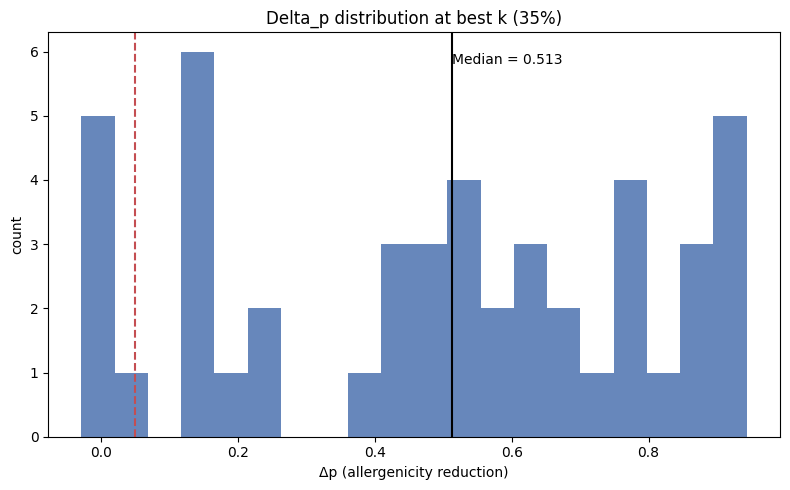

Saved delta_p distribution plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/delta_p_distribution.png


In [31]:
DELTA_P_DIST_PNG = ISM_RESULTS_DIR / "delta_p_distribution.png"
best_k_all_df = ig_validation_sweep_df.loc[ig_validation_sweep_df["k_pct"] == best_k_pct].copy()
median_delta_p = float(best_k_all_df["delta_p"].median())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(best_k_all_df["delta_p"], bins=20, color="#4C72B0", alpha=0.85)
ax.axvline(median_delta_p, color="black", linestyle="-", linewidth=1.5)
ax.axvline(MIN_DELTA_P, color="#C44E52", linestyle="--", linewidth=1.5)
ax.text(
    median_delta_p,
    ax.get_ylim()[1] * 0.95,
    f"Median = {median_delta_p:.3f}",
    color="black",
    ha="left",
    va="top",
    fontsize=10,
)
ax.set_title(f"Delta_p distribution at best k ({int(round(best_k_pct * 100))}%)")
ax.set_xlabel("Δp (allergenicity reduction)")
ax.set_ylabel("count")

plt.tight_layout()
plt.savefig(DELTA_P_DIST_PNG, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved delta_p distribution plot to: {DELTA_P_DIST_PNG}")


## Transition Analysis Figures

These standalone figures drill into the substitution landscape at three resolutions.

- Figure 2 summarizes which original amino acids tend to yield the largest allergenicity reduction when mutated to any reducing substitute.
- Figure 3 highlights the strongest amino-acid-to-amino-acid transitions that are both reducing and sufficiently supported.
- Figure 4 compresses that landscape into two interpretable class systems so we can compare coarse biochemical transition patterns.

Outputs written by this stage:
- `transition_panel1_by_residue.png` in `results/insilico_mutagenesis/`
- `top10_supported_aa_transitions.png` in `results/insilico_mutagenesis/`
- `top10_supported_aa_transitions.csv` in `results/insilico_mutagenesis/`
- `supplementary_transition_panel2_aa_heatmap.png` in `results/insilico_mutagenesis/`
- `transition_panel3_class_heatmaps.png` in `results/insilico_mutagenesis/`


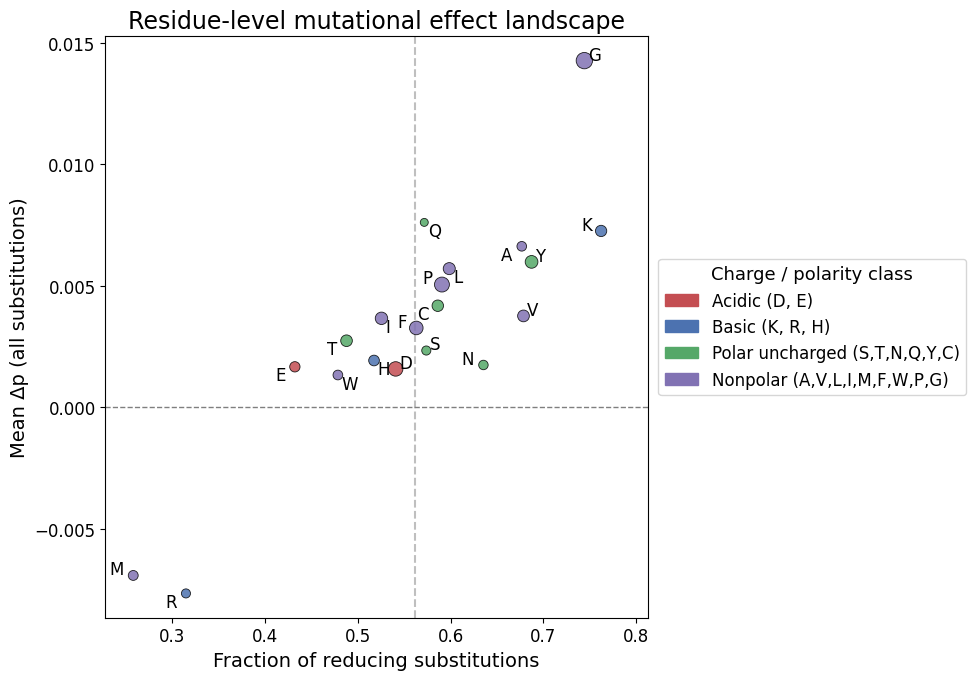

Saved scatter plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/transition_panel1_scatter.png


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.patches import Patch

SCATTER_PNG = ISM_RESULTS_DIR / "transition_panel1_scatter.png"

def plot_transition_scatter(summary_df: pd.DataFrame, output_path: Path) -> None:
    df = summary_df.copy()

    # Color mapping
    colors = df["class"].map(BAR_CLASS_COLORS).fillna("#999999")

    # Point sizes
    size_scale = 0.02
    sizes = df["n_total"] * size_scale

    # Larger global font sizes
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": 17,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    })

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        df["frac_reducing"],
        df["mean_delta_p_all"],
        s=sizes,
        c=colors,
        alpha=0.85,
        edgecolors="black",
        linewidth=0.6,
        zorder=3,
    )

    # Annotate ALL points
    # Use small alternating offsets to reduce overlap a bit
    offsets = [
        (0.004, 0.00025),
        (0.004, -0.00035),
        (-0.010, 0.00025),
        (-0.010, -0.00035),
    ]

    for i, (_, row) in enumerate(df.iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.text(
            row["frac_reducing"] + dx,
            row["mean_delta_p_all"] + dy,
            row["original_aa"],
            fontsize=12,
            ha="left" if dx >= 0 else "right",
            va="center",
            zorder=4,
        )

    # Reference lines
    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5, zorder=1)
    ax.axvline(df["frac_reducing"].mean(), color="gray", linestyle="--", alpha=0.5, zorder=1)

    # Labels and title
    ax.set_xlabel("Fraction of reducing substitutions")
    ax.set_ylabel("Mean Δp (all substitutions)")
    ax.set_title("Residue-level mutational effect landscape")

    # Slight padding so labels are not cut off
    x_min = max(0.0, float(df["frac_reducing"].min()) - 0.03)
    x_max = min(1.0, float(df["frac_reducing"].max()) + 0.05)
    y_min = float(df["mean_delta_p_all"].min()) - 0.001
    y_max = float(df["mean_delta_p_all"].max()) + 0.001
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Put legend outside the plot
    legend_handles = [
        Patch(color=color, label=label)
        for label, color in BAR_CLASS_COLORS.items()
    ]
    ax.legend(
        handles=legend_handles,
        title="Charge / polarity class",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

# Run
plot_transition_scatter(aa_transition_summary_df, SCATTER_PNG)
print(f"Saved scatter plot to: {SCATTER_PNG}")

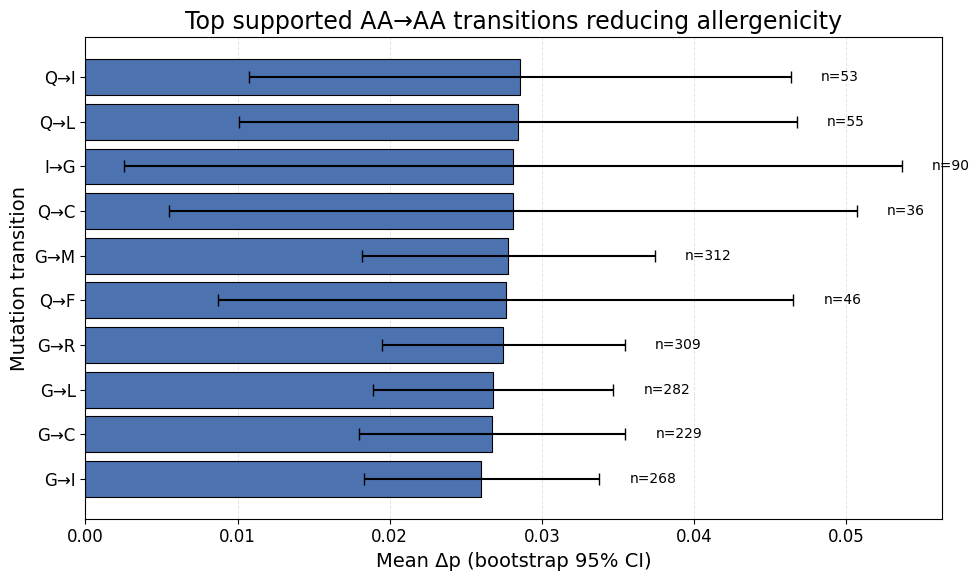

Saved top supported transition summary to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/top10_supported_aa_transitions.csv
Saved top supported transition plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/top10_supported_aa_transitions.png
original_aa mutant_aa   n  mean_delta_p  median_delta_p  std_delta_p  sem_delta_p  ci95_low  ci95_high  ci95_half_width transition_label
          Q         I  53      0.028565        0.008824     0.061002     0.008379  0.014181   0.046360         0.017795              Q→I
          Q         L  55      0.028425        0.009092     0.065605     0.008846  0.013911   0.046755         0.018330              Q→L
          I         G  90      0.028089        0.005703     0.103545     0.010915  0.012749   0.053640         0.025551              I→G
          Q         C  36

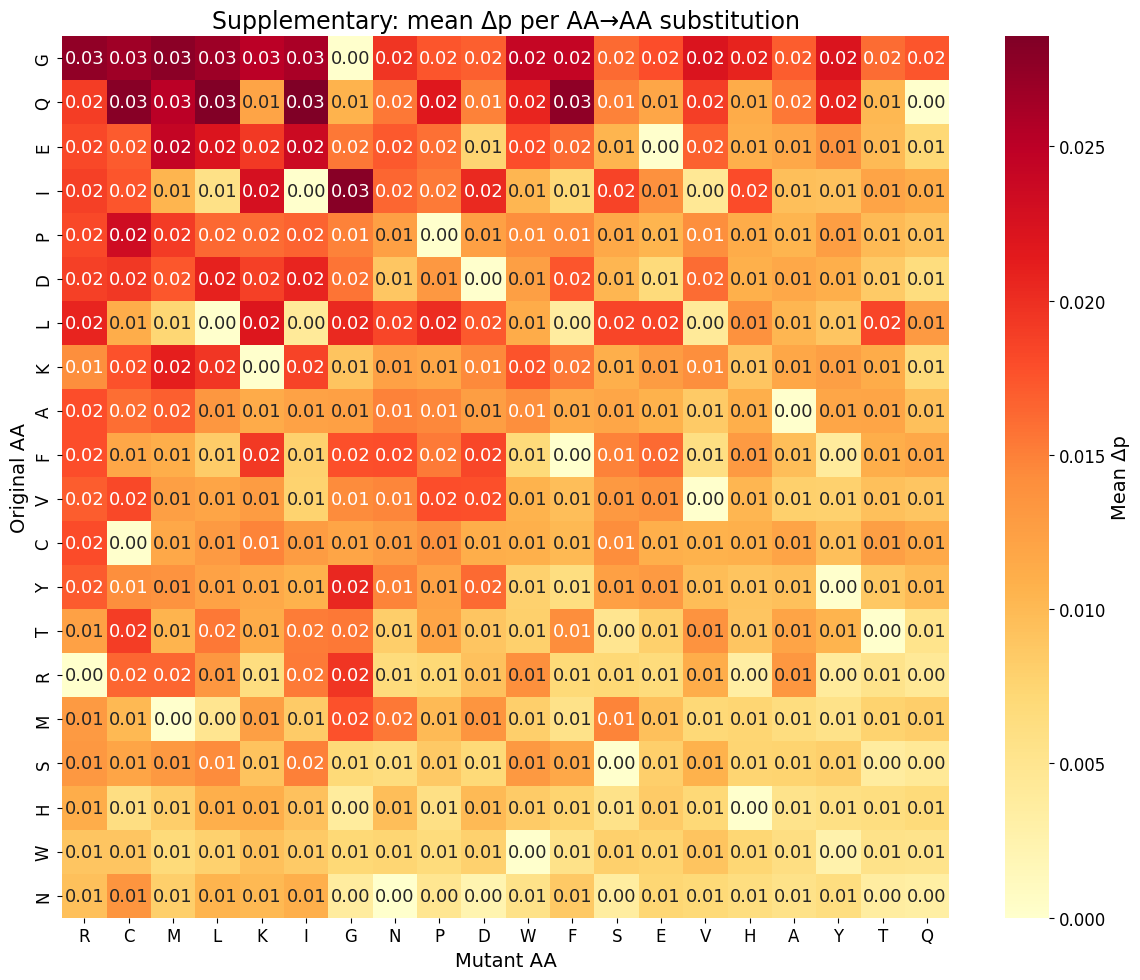

Saved supplementary AA→AA heatmap to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/supplementary_transition_panel2_aa_heatmap.png


In [47]:
TOP_SUPPORTED_TRANSITIONS_CSV = ISM_RESULTS_DIR / "top10_supported_aa_transitions.csv"
TOP_SUPPORTED_TRANSITIONS_PNG = ISM_RESULTS_DIR / "top10_supported_aa_transitions.png"
SUPPLEMENTARY_TRANSITION_P2_PNG = ISM_RESULTS_DIR / "supplementary_transition_panel2_aa_heatmap.png"
MIN_TRANSITION_SUPPORT = 20
BOOTSTRAP_N_RESAMPLES = 1000
BOOTSTRAP_RANDOM_STATE = 42


def bootstrap_ci_mean(values, n_bootstrap: int = BOOTSTRAP_N_RESAMPLES, random_state: int = BOOTSTRAP_RANDOM_STATE) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    mean_value = float(values.mean())
    if values.size == 1:
        return mean_value, mean_value, mean_value
    rng = np.random.default_rng(random_state)
    boot = np.empty(n_bootstrap, dtype=float)
    for idx in range(n_bootstrap):
        sample = rng.choice(values, size=values.size, replace=True)
        boot[idx] = sample.mean()
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return mean_value, float(ci_low), float(ci_high)


def summarize_top_supported_transitions(
    frame: pd.DataFrame,
    min_support: int = MIN_TRANSITION_SUPPORT,
    top_n: int = 10,
) -> pd.DataFrame:
    required_columns = {"original_aa", "mutant_aa", "delta_p", "reduces_allergenicity"}
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"transition_df is missing required columns: {sorted(missing_columns)}")

    reducing_df = frame.copy()
    reducing_df = reducing_df.loc[reducing_df["reduces_allergenicity"].fillna(False).astype(bool)].copy()
    reducing_df = reducing_df.dropna(subset=["original_aa", "mutant_aa", "delta_p"])
    reducing_df["original_aa"] = reducing_df["original_aa"].astype(str)
    reducing_df["mutant_aa"] = reducing_df["mutant_aa"].astype(str)
    reducing_df = reducing_df.loc[reducing_df["original_aa"] != reducing_df["mutant_aa"]].copy()

    if reducing_df.empty:
        return pd.DataFrame(
            columns=["original_aa", "mutant_aa", "n", "mean_delta_p", "median_delta_p", "std_delta_p", "sem_delta_p", "ci95_low", "ci95_high", "ci95_half_width", "transition_label"]
        )

    summary_df = (
        reducing_df.groupby(["original_aa", "mutant_aa"], as_index=False)["delta_p"]
        .agg(
            n="count",
            mean_delta_p="mean",
            median_delta_p="median",
            std_delta_p="std",
        )
    )
    summary_df["std_delta_p"] = summary_df["std_delta_p"].fillna(0.0)
    summary_df = summary_df.loc[summary_df["n"] >= int(min_support)].copy()
    summary_df["sem_delta_p"] = summary_df["std_delta_p"] / np.sqrt(summary_df["n"].clip(lower=1))

    ci_rows = []
    for row in summary_df.itertuples(index=False):
        group_values = reducing_df.loc[
            (reducing_df["original_aa"] == row.original_aa) &
            (reducing_df["mutant_aa"] == row.mutant_aa),
            "delta_p",
        ].to_numpy(dtype=float)
        _, ci_low, ci_high = bootstrap_ci_mean(
            group_values,
            n_bootstrap=BOOTSTRAP_N_RESAMPLES,
            random_state=BOOTSTRAP_RANDOM_STATE,
        )
        ci_rows.append({
            "original_aa": row.original_aa,
            "mutant_aa": row.mutant_aa,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
        })

    ci_df = pd.DataFrame(ci_rows)
    summary_df = summary_df.merge(ci_df, on=["original_aa", "mutant_aa"], how="left")
    summary_df["ci95_half_width"] = summary_df["ci95_high"] - summary_df["mean_delta_p"]
    summary_df["transition_label"] = summary_df["original_aa"] + "→" + summary_df["mutant_aa"]
    summary_df = summary_df.sort_values(
        ["mean_delta_p", "n", "median_delta_p", "transition_label"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    return summary_df.head(top_n).copy()


def plot_top_supported_transitions(summary_df: pd.DataFrame, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))

    if summary_df.empty:
        ax.text(0.5, 0.5, "No supported reducing transitions passed the minimum support threshold.", ha="center", va="center", fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.show()
        return

    plot_df = summary_df.sort_values(["mean_delta_p", "n"], ascending=[True, True]).reset_index(drop=True)
    y_positions = np.arange(len(plot_df))
    bar_container = ax.barh(
        y_positions,
        plot_df["mean_delta_p"],
        xerr=plot_df["ci95_half_width"],
        color="#4C72B0",
        edgecolor="black",
        linewidth=0.8,
        error_kw={"ecolor": "black", "elinewidth": 1.5, "capsize": 4},
    )
    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_df["transition_label"])
    ax.set_xlabel("Mean Δp (bootstrap 95% CI)")
    ax.set_ylabel("Mutation transition")
    ax.set_title("Top supported AA→AA transitions reducing allergenicity")
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)

    x_values = plot_df["mean_delta_p"] + plot_df["ci95_half_width"].fillna(0.0)
    text_offset = max(float(plot_df["mean_delta_p"].max()) * 0.02, 0.002)
    for y_pos, x_value, n_value in zip(y_positions, x_values, plot_df["n"]):
        ax.text(float(x_value) + text_offset, y_pos, f"n={int(n_value)}", va="center", ha="left", fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


top_supported_transitions_df = summarize_top_supported_transitions(
    frame=transition_df,
    min_support=MIN_TRANSITION_SUPPORT,
    top_n=10,
)
top_supported_transitions_df.to_csv(TOP_SUPPORTED_TRANSITIONS_CSV, index=False)
plot_top_supported_transitions(top_supported_transitions_df, TOP_SUPPORTED_TRANSITIONS_PNG)

print(f"Saved top supported transition summary to: {TOP_SUPPORTED_TRANSITIONS_CSV}")
print(f"Saved top supported transition plot to: {TOP_SUPPORTED_TRANSITIONS_PNG}")
print(top_supported_transitions_df.to_string(index=False))

# Supplementary full AA→AA heatmap retained for detailed inspection.
fig, ax = plt.subplots(figsize=(12, 10))
supplementary_heatmap_df = (
    transition_df.loc[transition_df["reduces_allergenicity"].fillna(False).astype(bool)].copy()
    .groupby(["original_aa", "mutant_aa"], as_index=False)["delta_p"]
    .mean()
    .pivot(index="original_aa", columns="mutant_aa", values="delta_p")
    .reindex(index=AA_ORDER, columns=AA_ORDER)
)
row_order = supplementary_heatmap_df.mean(axis=1).sort_values(ascending=False).index.tolist()
col_order = supplementary_heatmap_df.mean(axis=0).sort_values(ascending=False).index.tolist()
supplementary_heatmap_df = supplementary_heatmap_df.loc[row_order, col_order].fillna(0.0)
sns.heatmap(supplementary_heatmap_df, cmap="YlOrRd", annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "Mean Δp"})
ax.set_title("Supplementary: mean Δp per AA→AA substitution")
ax.set_xlabel("Mutant AA")
ax.set_ylabel("Original AA")

plt.tight_layout()
plt.savefig(SUPPLEMENTARY_TRANSITION_P2_PNG, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved supplementary AA→AA heatmap to: {SUPPLEMENTARY_TRANSITION_P2_PNG}")


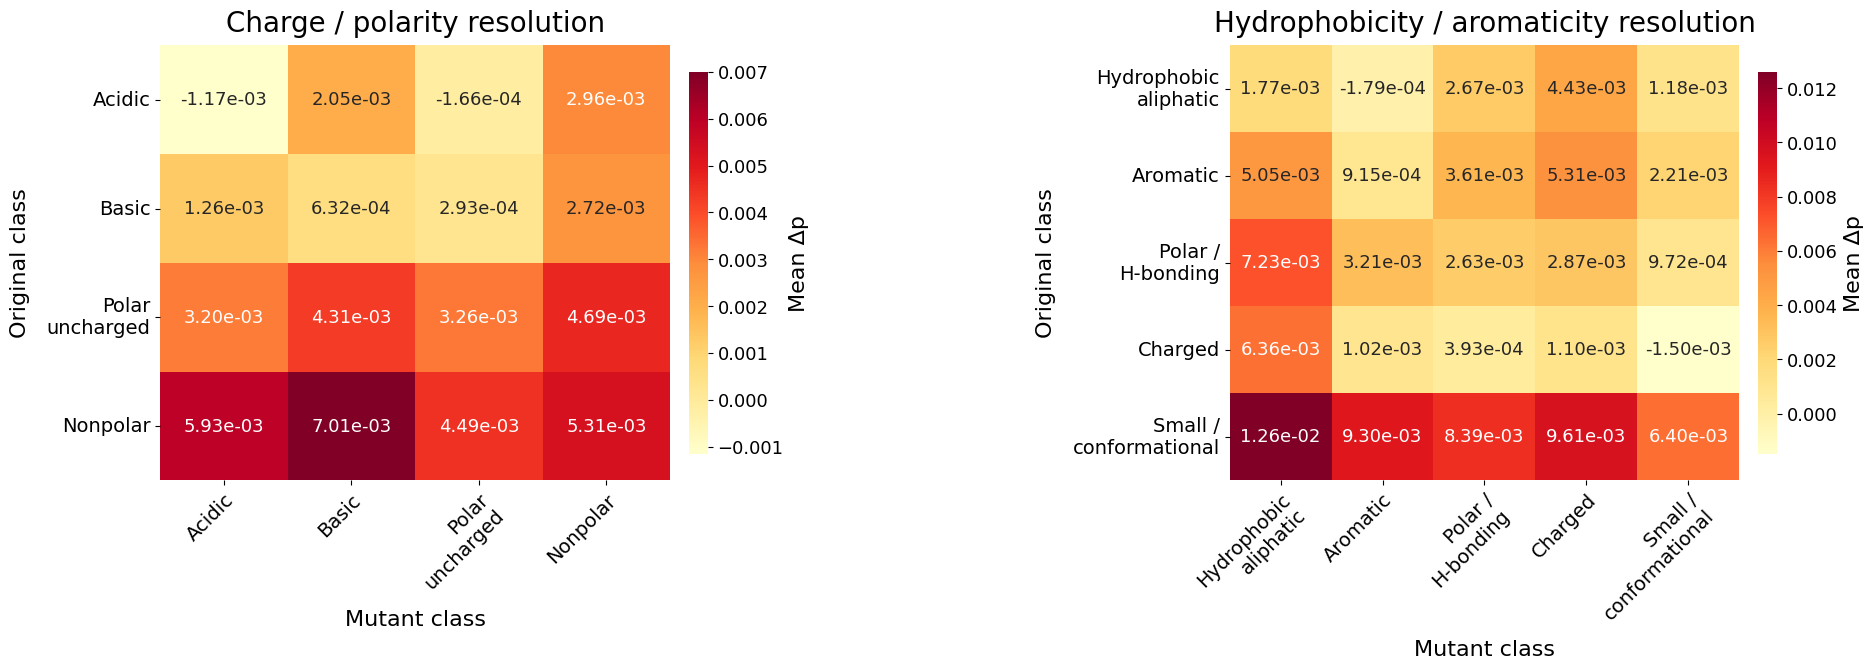

Saved transition panel 3 figure to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/transition_panel3_class_heatmaps.png


In [40]:
TRANSITION_P3_PNG = ISM_RESULTS_DIR / "transition_panel3_class_heatmaps.png"

CLASS_LABELS_COMPACT = {
    "Acidic": "Acidic",
    "Basic": "Basic",
    "Polar uncharged": "Polar\nuncharged",
    "Nonpolar": "Nonpolar",
    "Strongly hydrophobic aliphatic": "Hydrophobic\naliphatic",
    "Aromatic": "Aromatic",
    "Polar / H-bonding": "Polar /\nH-bonding",
    "Charged": "Charged",
    "Small / conformationally special": "Small /\nconformational",
}


HEATMAP_TITLE_FONTSIZE = 20
HEATMAP_LABEL_FONTSIZE = 16
HEATMAP_TICK_FONTSIZE = 14
HEATMAP_ANNOT_FONTSIZE = 13
COLORBAR_LABEL_FONTSIZE = 16
COLORBAR_TICK_FONTSIZE = 13


def _apply_compact_class_labels(ax, matrix: pd.DataFrame) -> None:
    x_labels = [CLASS_LABELS_COMPACT.get(label, label) for label in matrix.columns]
    y_labels = [CLASS_LABELS_COMPACT.get(label, label) for label in matrix.index]
    ax.set_xticklabels(x_labels, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(y_labels, rotation=0)
    ax.tick_params(axis="both", labelsize=HEATMAP_TICK_FONTSIZE)


fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(19, 7.5))

charge_polarity_matrix = build_normalized_transition_matrix(transition_df, CHARGE_POLARITY_CLASSES)
heatmap_left = sns.heatmap(
    charge_polarity_matrix,
    cmap="YlOrRd",
    annot=True,
    fmt=".2e",
    annot_kws={"fontsize": HEATMAP_ANNOT_FONTSIZE},
    ax=ax_left,
    cbar_kws={"label": "Mean Δp", "shrink": 0.88, "pad": 0.03},
)
_apply_compact_class_labels(ax_left, charge_polarity_matrix)
ax_left.set_title("Charge / polarity resolution", fontsize=HEATMAP_TITLE_FONTSIZE, pad=10)
ax_left.set_xlabel("Mutant class", fontsize=HEATMAP_LABEL_FONTSIZE, labelpad=12)
ax_left.set_ylabel("Original class", fontsize=HEATMAP_LABEL_FONTSIZE, labelpad=12)
left_cbar = heatmap_left.collections[0].colorbar
left_cbar.set_label("Mean Δp", fontsize=COLORBAR_LABEL_FONTSIZE)
left_cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)

hydrophobicity_matrix = build_normalized_transition_matrix(transition_df, HYDROPHOBICITY_AROMATICITY_CLASSES)
heatmap_right = sns.heatmap(
    hydrophobicity_matrix,
    cmap="YlOrRd",
    annot=True,
    fmt=".2e",
    annot_kws={"fontsize": HEATMAP_ANNOT_FONTSIZE},
    ax=ax_right,
    cbar_kws={"label": "Mean Δp", "shrink": 0.88, "pad": 0.03},
)
_apply_compact_class_labels(ax_right, hydrophobicity_matrix)
ax_right.set_title("Hydrophobicity / aromaticity resolution", fontsize=HEATMAP_TITLE_FONTSIZE, pad=10)
ax_right.set_xlabel("Mutant class", fontsize=HEATMAP_LABEL_FONTSIZE, labelpad=12)
ax_right.set_ylabel("Original class", fontsize=HEATMAP_LABEL_FONTSIZE, labelpad=12)
right_cbar = heatmap_right.collections[0].colorbar
right_cbar.set_label("Mean Δp", fontsize=COLORBAR_LABEL_FONTSIZE)
right_cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)

plt.subplots_adjust(wspace=0.72, bottom=0.32, left=0.08, right=0.97, top=0.90)
plt.savefig(TRANSITION_P3_PNG, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved transition panel 3 figure to: {TRANSITION_P3_PNG}")


## Per-Protein Deep Dive CSV

This section saves a compact table for the strongest validated proteins, including the selected positions and the top reducing substitutions at each position.

Output written by this stage:
- `per_protein_deep_dive.csv` in `results/insilico_mutagenesis/`


In [42]:
PER_PROTEIN_DEEP_DIVE_CSV = ISM_RESULTS_DIR / "per_protein_deep_dive.csv"

top_validated_df = best_k_validation_df.sort_values("delta_p", ascending=False).head(10).copy()
deep_dive_rows = []
for row in top_validated_df.itertuples(index=False):
    sequence_id = str(row.sequence_id)
    top_k_indices = json.loads(row.top_k_indices_json)
    protein_mut_df = annotated_mutagenesis_df.loc[annotated_mutagenesis_df["sequence_id"] == sequence_id].copy()
    for position in top_k_indices:
        position_df = protein_mut_df.loc[
            (protein_mut_df["position"] == position) & (protein_mut_df["reduces_allergenicity"])
        ].sort_values("delta_p", ascending=False).head(3)
        for mutant_row in position_df.itertuples(index=False):
            deep_dive_rows.append(
                {
                    "sequence_id": sequence_id,
                    "masking_delta_p": float(row.delta_p),
                    "position": int(mutant_row.position),
                    "original_aa": mutant_row.original_aa,
                    "mutant_aa": mutant_row.mutant_aa,
                    "p_base": float(mutant_row.p_base),
                    "p_mutant": float(mutant_row.p_mutant),
                    "delta_p": float(mutant_row.delta_p),
                    "property_change": mutant_row.property_change,
                }
            )

per_protein_deep_dive_df = pd.DataFrame(
    deep_dive_rows,
    columns=[
        "sequence_id",
        "masking_delta_p",
        "position",
        "original_aa",
        "mutant_aa",
        "p_base",
        "p_mutant",
        "delta_p",
        "property_change",
    ],
)
per_protein_deep_dive_df = per_protein_deep_dive_df.sort_values(
    ["sequence_id", "masking_delta_p", "position", "delta_p"],
    ascending=[True, False, True, False],
).reset_index(drop=True)
per_protein_deep_dive_df.to_csv(PER_PROTEIN_DEEP_DIVE_CSV, index=False)

print(f"Saved per-protein deep dive CSV to: {PER_PROTEIN_DEEP_DIVE_CSV}")
print(
    f"Summary: proteins={top_validated_df['sequence_id'].nunique()}, "
    f"rows={len(per_protein_deep_dive_df)}"
)
print(per_protein_deep_dive_df.head().to_string(index=False))


NameError: name 'annotated_mutagenesis_df' is not defined

## Output Folder

All files created by this notebook are now grouped under `results/insilico_mutagenesis/`. This makes the analysis outputs easier to inspect and keeps them separate from the general probe and training artifacts.


In [54]:
for out_path in sorted(ISM_RESULTS_DIR.glob("*")):
    print(out_path)


/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/.DS_Store
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/delta_p_distribution.png
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/ig_validation_sweep.csv
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/ig_validation_sweep.png
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/ig_vs_random_baseline.csv
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/insilico_mutagenesis/ig_vs_random_baseline.png
/Users/jianzhouyao/Library/Mobile Documents